# Inverse Scattering Problem

Authored by Xianjin Yang

In [1]:
from pyKoLesky.ordering import maximin
from pyKoLesky.cholesky import sparsity_pattern,sparse_cholesky,non_zeros
import torch
import torch.nn as nn
import torch.optim as optim
from numpy import *
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sched import scheduler

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Using device:", device)

torch.set_default_dtype(torch.float64)

# Parameters
N = 7  # Number of grid points
L = 1.0  # Length of the domain [0, 1]
rho = 100  # Sparsity factor defined by ln(N/epsilon)
num_newton_iter = 10  # Number of classical Newton iterations for Data generation
num_realizations = 1000  # Number of realizations
num_training = num_realizations * num_newton_iter - 250  # Number of training samples
num_folds = 5  # For cross-validation


# Create 2D grid
x = torch.linspace(0, L, N + 1, device=device)[:-1]  # shape (N,)
y = torch.linspace(0, L, N + 1, device=device)[:-1]  # shape (N,)
w = 1

X, Y = torch.meshgrid(x, y, indexing='ij')  # X,Y are N x N tensors
dx = x[1] - x[0]  # Grid spacing
X_coords = torch.stack([X.flatten(), Y.flatten()], dim=1)  #  Flatten coordinates, shape (N*N, 2)


# Sparsity pattern
Perm, lengths = maximin(X_coords)  # Calculating MaxMin Ordering
sparsity = sparsity_pattern(X_coords[Perm], lengths, rho)  # Calculating the sparsity pattern
nonzeros_indices = non_zeros(N*N, sparsity)  # Calculating the non zero indices


# Gaussian Process class with learnable nugget
class GaussianProcess(nn.Module):
    def __init__(self, length_scale=1.0, nugget_init=1e-6, nu=3 / 2):
        super(GaussianProcess, self).__init__()
        self.length_scale = nn.Parameter(torch.ones(N*N) * length_scale)
        # self.length_scale = nn.Parameter(torch.ones(1) * length_scale)
        # self.nugget = nn.Parameter(torch.tensor(nugget_init))
        self.nugget = torch.tensor(nugget_init)
        self.nu = nu

    def matern_kernel(self, X1, X2):
        # Compute pairwise Euclidean distance between points in scaled X1 and X2
        X1_scaled = X1 * self.length_scale
        X2_scaled = X2 * self.length_scale
        pairwise_dists = torch.cdist(X1_scaled, X2_scaled, p=2)

        if self.nu == 3 / 2:
            scale = torch.sqrt(torch.tensor(3.0)) * pairwise_dists
            K = (1 + scale) * torch.exp(-scale)
        else:
            raise ValueError("Only nu=3/2 is supported.")
        return K

    def fit(self, X_train, y_train):
        # Kernel matrices with learnable nugget
        K_train = self.matern_kernel(X_train, X_train) + torch.eye(X_train.shape[0]) * self.nugget
        # L = torch.linalg.cholesky(K_train)
        # alpha_train = torch.linalg.solve_triangular(L, y_train, upper=False)
        alpha_train = torch.linalg.solve(K_train, y_train)
        self.alpha_train = alpha_train
        self.X_train = X_train

    def forward(self, X_val):
        K_val_train = self.matern_kernel(X_val, self.X_train)
        y_pred_val = K_val_train @ self.alpha_train
        return y_pred_val


# Generate the covariance matrix using the Matérn kernel
def generate_covariance_matrix(kernel_func, x, length_scale):
    return kernel_func(x.unsqueeze(1), x.unsqueeze(1), length_scale)


def generate_f_u_from_gp(
    num_realizations: int,
    N: int,
    kernel_func,
    length_scale: float
):
    """
    Generate:
      - f: of shape (num_realizations, 16*(N-1)^2)
      - u: of shape (num_realizations, N^2), with u > 0 by construction
        (exponentiating the GP samples).

    We build two separate index arrays x_f, x_u to form two covariance kernels:
      K_f for f, and K_u for u.

    Parameters
    ----------
    num_realizations : int
        Number of random samples to generate.
    N : int
        Grid size or parameter controlling the dimension.
    kernel_func : callable
        A function kernel_func(x1, x2, length_scale) -> Covariance matrix.
        Must handle x1, x2 of shape (M, 1) consistently.
    length_scale : float
        Length scale parameter for the kernel.

    Returns
    -------
    f_realizations : Tensor of shape (num_realizations, 16*(N-1)^2)
    u_realizations : Tensor of shape (num_realizations, N^2),
                     guaranteed positive by exponentiation.
    """

    # 1) Dimensions we want
    f_dim = N**2
    u_dim = N**2

    # 2) Create index arrays for each
    #    Here we just use arange(...) as a simple 1D "spatial" index
    x_f = torch.arange(f_dim, dtype=torch.double)
    x_u = torch.arange(u_dim, dtype=torch.double)

    # 3) Build covariance K_f for f
    K_f = kernel_func(x_f.unsqueeze(1), x_f.unsqueeze(1), length_scale)
    # Add a small diagonal jitter for numerical stability
    K_f = K_f + 1e-3 * torch.eye(f_dim, dtype=torch.double)
    L_f = torch.linalg.cholesky(K_f)  # shape: (f_dim, f_dim)

    # 4) Build covariance K_u for u
    K_u = kernel_func(x_u.unsqueeze(1), x_u.unsqueeze(1), length_scale)
    K_u = K_u + 1e-3 * torch.eye(u_dim, dtype=torch.double)
    L_u = torch.linalg.cholesky(K_u)  # shape: (u_dim, u_dim)

    # 5) Draw standard normal samples for f and u
    #    shape: (num_realizations, f_dim) and (num_realizations, u_dim)
    f_standard = torch.randn(num_realizations, f_dim, dtype=torch.double)
    u_standard = torch.randn(num_realizations, u_dim, dtype=torch.double)

    # 6) Correlate by applying Cholesky
    #    (L_f @ f_standard.T) => shape (f_dim, num_realizations)
    #    => transpose => (num_realizations, f_dim)
    f_realizations = (L_f @ f_standard.T).T
    u_realizations = (L_u @ u_standard.T).T

    # 7) Exponentiate u to ensure positivity
    u_realizations = torch.exp(u_realizations)
    f_tmp = torch.exp(f_realizations)
    f_realizations = torch.cat([(forward_map_alpha_to_flux(f_tmp[i, :])).unsqueeze(0)
                     for i in range(num_realizations)], dim=0)

    return f_realizations, u_realizations




def build_2d_laplacian(N, device, dtype):
    """
    Build a (N^2 x N^2) matrix L that represents
    the 5-point Laplacian on an N x N grid with
    zero-Dirichlet boundary or something similar.
    """
    if device is None:
        device = torch.device('cpu')

    # Number of points
    M = N * N

    # We can store in a sparse format
    # We'll build (row_index, col_index, values) and
    # then convert to a sparse_coo_tensor. For simplicity,
    # here's a dense approach for smaller N.

    L = torch.zeros((M, M), dtype=dtype, device=device)

    def idx(i, j):
        return i*N + j

    for i in range(N):
        for j in range(N):
            k = idx(i, j)
            # "Center"
            L[k, k] = -4.0

            # Up neighbor
            if i > 0:
                L[k, idx(i-1, j)] = 1.0
            # Down neighbor
            if i < N-1:
                L[k, idx(i+1, j)] = 1.0
            # Left neighbor
            if j > 0:
                L[k, idx(i, j-1)] = 1.0
            # Right neighbor
            if j < N-1:
                L[k, idx(i, j+1)] = 1.0

    return L

Using device: cpu


In [2]:
def assemble_A(a, h, omega):
    N = a.shape[0]
    M = N*N + 4*N
    off  = -1.0 * torch.ones(N-1, dtype=a.dtype, device=a.device)
    diag =  2.0 * torch.ones(N,   dtype=a.dtype, device=a.device)
    T1   = torch.diag(off, -1) + torch.diag(diag,0) + torch.diag(off,1)
    I    = torch.eye(N, dtype=a.dtype, device=a.device)
    Lap2D= torch.kron(I, T1) + torch.kron(T1, I)
    A_int= Lap2D/(h*h) - omega**2 * torch.diag(a.flatten())
    idx = torch.arange(N, device=a.device)
    B   = torch.zeros((N*N, 4*N), dtype=a.dtype, device=a.device)
    # up (north, i=0)
    B[0*N + idx,       idx      ] = -1.0/(h*h)
    # bottom (south, i=N-1)
    B[(N-1)*N + idx,   N + idx  ] = -1.0/(h*h)
    # left (west, j=0)
    B[idx*N + 0,       2*N + idx] = -1.0/(h*h)
    # right (east, j=N-1)
    B[idx*N + (N-1),   3*N + idx] = -1.0/(h*h)
    A = torch.zeros((M, M), dtype=a.dtype, device=a.device)
    A[:N*N, :N*N]   = A_int
    A[:N*N, N*N:]   = B
    A[N*N:,  N*N:]  = torch.eye(4*N, dtype=a.dtype, device=a.device)
    return A

def assemble_F(N, h, device='cpu'):
    M = N*N + 4*N
    F = torch.zeros((4*N, M), dtype=torch.float64, device=device)
    ar = torch.arange(N, device=device)
    # 1) UP (north, i=0)
    F[0*N + ar,     0*N + ar]           = -1.0/h
    F[0*N + ar,     N*N + 0*N + ar]     = +1.0/h
    # 2) BOTTOM (south, i=N-1)
    F[1*N + ar,     (N-1)*N + ar]       = -1.0/h
    F[1*N + ar,     N*N + 1*N + ar]     = +1.0/h
    # 3) LEFT (west, j=0)
    F[2*N + ar,     ar*N + 0]           = -1.0/h
    F[2*N + ar,     N*N + 2*N + ar]     = +1.0/h
    # 4) RIGHT (east, j=N-1)
    F[3*N + ar,     ar*N + (N-1)]       = -1.0/h
    F[3*N + ar,     N*N + 3*N + ar]     = +1.0/h
    return F

def assemble_G(N, device='cpu'):
    M = N*N + 4*N
    G = torch.zeros((M, 4*N), dtype=torch.float64, device=device)
    G[N*N:, :] = torch.eye(4*N, dtype=torch.float64, device=device)
    return G

def forward_map_alpha_to_flux(alpha_flat, omega=1.0):
    """
    Given a flattened potential alpha (shape [N^2]), build the
    discrete operator A corresponding to the PDE
         -Delta u - w * alpha(x) * u = 0
    on a uniform N x N grid in [0, L]^2 with Dirichlet boundary.
    Then build the 'flux' matrix that extracts partial u/partial n
    on the boundary.  Finally, compute
         flux_matrix @ A^{-1} @ G
    which maps boundary Dirichlet data (g) to normal derivatives
    on the boundary.

    Parameters:
    -----------
    alpha_flat : (N^2,) torch.Tensor
        Flattened potential a(x) on the grid.
    N : int
        Number of grid points per dimension.
    L : float
        Length of the square domain [0, L] x [0, L].
    w : float
        The constant multiplier for the potential term.
    device : torch.device, optional
        Device on which to allocate Tensors.

    Returns:
    --------
    flux_matrix_A_inv_flat : torch.Tensor
        Flattened array of shape (4*(N-1) * N^2,) corresponding to
        flux_matrix @ A^{-1} @ G, i.e. the forward operator that
        maps boundary Dirichlet data to boundary normal derivatives.
    """
    # Reshape alpha
    alpha = alpha_flat.reshape(N, N)

    h = 1.0/(N+1)

    A = assemble_A(alpha, h, omega)
    G = assemble_G(N, device=alpha.device)
    F = assemble_F(N, h, device=alpha.device)
    X = torch.linalg.solve(A, G)
    flux_matrix_A_inv =  F @ X

    # Flatten the result
    flux_matrix_A_inv_flat = flux_matrix_A_inv.flatten()
    return flux_matrix_A_inv_flat


In [3]:
from torch.autograd import grad
from torch.func import jacfwd, jacrev

def newton_method_for_F(Lambda_g, gamma_0, forward_map_alpha_to_flux, lambda_reg, learning_rate, max_iter, c1, beta, delta, tol=1e-20):
    gamma_0_flat = gamma_0.flatten()
    gamma_n = gamma_0_flat.clone()
    L = build_2d_laplacian(N, device = device, dtype = torch.float64)

    for i in range(max_iter):
        # Solve the Newton iteration
        F_n = forward_map_alpha_to_flux(gamma_n) - Lambda_g
        F_n = F_n.detach()
        DF_n = torch.func.jacfwd(forward_map_alpha_to_flux)(gamma_n).detach()

        # Move or ensure DF_n is on GPU
        DF_n = DF_n.to(device)
        F_n = F_n.to(device)

        D = DF_n.T @ DF_n
        A = D + lambda_reg * torch.eye(N * N, device=device, dtype=DF_n.dtype) - delta * L
        b = - DF_n.T @ F_n - delta * L @ gamma_n

        # D = DF_n.T @ DF_n
        # A = D + lambda_reg * torch.eye(N * N, device=device, dtype=torch.float64)
        # b = - DF_n.T @ F_n

        delta_gamma = torch.linalg.solve(A, b)

        alpha = learning_rate  # Initial step size
        gamma_trial = gamma_n + alpha * delta_gamma
        F_n_delta = forward_map_alpha_to_flux(gamma_trial) - Lambda_g


        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(b, delta_gamma):
            alpha *= beta  # Reduce step size

            gamma_trial = gamma_n + alpha * delta_gamma
            F_n_delta = forward_map_alpha_to_flux(gamma_trial) - Lambda_g

            # # Check convergence
            # if torch.norm(alpha) < 0.000001:
            #     print("Converged!")
            #     break

        # Update rule: v_{n+1} = v_n + delta_v
        gamma_n += alpha * delta_gamma.squeeze()
        # if i % 100 == 0:  # Check if i is divisible by 100
        #     print(alpha)

        # if i % 100 == 0:  # Check if i is divisible by 100
        #     print(torch.norm(gamma_n - gamma_exact) / torch.norm(gamma_exact))
        #
            # cond_number = torch.linalg.cond(A)
            # print(f"Condition number: {cond_number.item()}")
            #
            # rank = torch.linalg.matrix_rank(A)
            # print(f"Matrix rank: {rank} / {A.shape[-1]}")


    gamma = gamma_n.reshape(N, N)
    return gamma


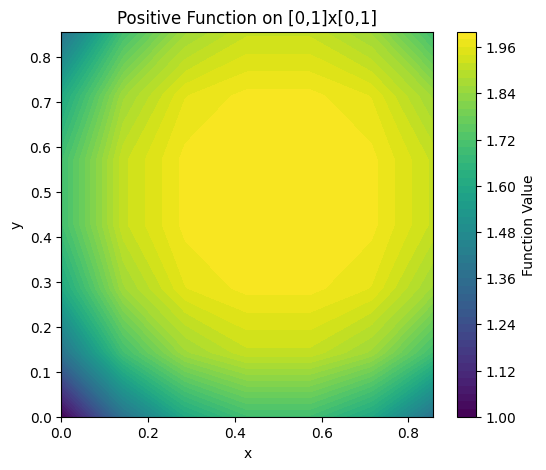

tensor(2.5578e-13)


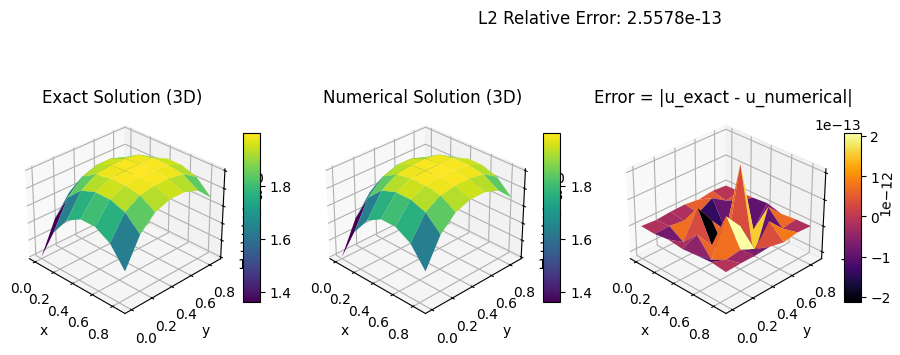

In [4]:
# define c1,c2,c3 => c1+c2+c3=1
c_1= 1/6
c_2= 1/6
c_3= 1/6
c_4 = 1/6
c_5 = 1/6
c_6 = 1/6


import matplotlib.pyplot as plt

# Define a positive function (e.g., Gaussian-like function)
# Gamma = torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.1) + 1.0  # A
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.cos(torch.pi * Y)
# Gamma = 3.0 + 0.5 * torch.sin(2 * torch.pi * X) * torch.sin(2 * torch.pi * Y)
# Gamma = 1.0 + torch.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2)
# Gamma = 1.0 + torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.2)
# Gamma = 1.0 + (X ** 2 + Y ** 2)
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.exp(-Y)
# Gamma = 1.0 + torch.abs(torch.sin(torch.pi * X) + torch.cos(torch.pi * Y))
# Gamma = 1.0 + torch.sin(torch.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2) * 1 * torch.pi)
Gamma = 1.0 + torch.cos(((X - 0.5) ** 2 + (Y - 0.5) ** 2 ) * 1 * torch.pi)
# Gamma = 1.0 + torch.relu(torch.sin(2 * torch.pi * X) * torch.cos(2 *torch.pi * Y))
# Gamma = 1.0 + torch.log1p((X - 0.5) ** 2 + (Y - 0.5) ** 2)
# Gamma = 1.0 + torch.abs(torch.sin(2 * torch.pi * X) * torch.cos(2 *torch.pi * Y))

# Flatten the function values
gamma_exact = Gamma.flatten()
Lambda_g = forward_map_alpha_to_flux(gamma_exact)
gamma_0 = torch.ones((N, N), device=device)

gamma_0 = gamma_0.to(device)
Lambda_g = Lambda_g.to(device)

#
# # Initial guess with relative error
# eps = 0.0
# relative_error = 0.001
# mean_gamma1 = torch.mean(Gamma)  # Average value of Gamma2
# noise_std1 = relative_error * mean_gamma1  # Standard deviation of noise
# noise1 = torch.randn_like(Gamma) * noise_std1 # Add Gaussian noise with calculated standard deviation
# gamma_0 = Gamma + noise1
# gamma_0 = torch.clamp(gamma_0, min=0.0) # Ensure Gamma2_noisy remains positive

# Plot for visualization
plt.figure(figsize=(6, 5))
plt.contourf(X.cpu(), Y.cpu(), Gamma.cpu(), levels=50, cmap="viridis")
plt.colorbar(label="Function Value")
plt.title("Positive Function on [0,1]x[0,1]")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


gamma_comp = newton_method_for_F(Lambda_g, gamma_0, forward_map_alpha_to_flux, lambda_reg=1e-20, learning_rate=1.0,
                                 max_iter=50, c1=1e-4, beta=0.5, delta=0, tol=1e-16)

#
# gamma_comp = newton_method_for_F(Lambda_g, gamma_comp, forward_map_alpha_to_flux, lambda_reg=1e-5, learning_rate=1.0,
#                                  max_iter=1000, c1=1e-4, beta=0.5, delta=0, tol=1e-16)


gamma_comp[0,0] = Gamma[0,0]
gamma_comp[0,-1] = Gamma[0,-1]
gamma_comp[-1,0] = Gamma[-1,0]
gamma_comp[-1,-1] = Gamma[-1,-1]

l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)
print(l2_error)

X_np = X.numpy()
Y_np = Y.numpy()

u_exact_np = Gamma.numpy()
u_numerical_np = gamma_comp.numpy()
error = gamma_comp - Gamma
error_np = error.numpy()
l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)

fig = plt.figure(figsize=(12, 4))

# 3D plot of Exact Solution
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, u_exact_np, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Exact Solution (3D)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# Adjust viewing angle so that (1,1) is more towards the front
ax1.view_init(elev=30, azim=-45)

# 3D plot of Numerical Solution
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
surf2 = ax2.plot_surface(X_np, Y_np, u_numerical_np, cmap="viridis", linewidth=0, antialiased=True)
ax2.set_title("Numerical Solution (3D)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
ax2.view_init(elev=30, azim=-45)

# 3D plot of Error
ax3 = fig.add_subplot(1, 4, 3, projection='3d')
surf3 = ax3.plot_surface(X_np, Y_np, error_np, cmap="inferno", linewidth=0, antialiased=True)
ax3.set_title("Error = |u_exact - u_numerical|")
ax3.set_xlabel('x')
ax3.set_ylabel('y')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)
ax3.view_init(elev=30, azim=-45)

# # 3D plot of Exact Solution
# ax1 = fig.add_subplot(1, 4,4, projection='3d')
# surf1 = ax1.plot_surface(X_np, Y_np, u_numerical_2, cmap="viridis", linewidth=0, antialiased=True)
# ax1.set_title("Numerical Solution 2 (3D)")
# ax1.set_xlabel('x')
# ax1.set_ylabel('y')
# fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# # Adjust viewing angle so that (1,1) is more towards the front
# ax1.view_init(elev=30, azim=-45)
#
# ax3.set_ylim(1, 0)
# ax2.set_ylim(1, 0)
# ax1.set_ylim(1, 0)

plt.suptitle(f"L2 Relative Error: {l2_error:.4e}")
plt.tight_layout()
plt.show()

In [5]:
import math

def classical_newton_method_gen_data(Lambda_g_flat, gamma_0_flat, forward_map_alpha_to_flux, lambda_reg, learning_rate,
                                     max_iter):
    gamma_n = gamma_0_flat.clone()

    # Initialize a matrix to store the solution at each iteration
    solutions_matrix = torch.zeros((max_iter + 1, gamma_0_flat.numel()))  # numel() gives the number of elements in v0

    # Store the current solution in the matrix
    solutions_matrix[0, :] = gamma_n.view(-1)  # Store the flattened solution

    for i in range(max_iter):
        # Solve the Newton iteration
        F_n = forward_map_alpha_to_flux(gamma_n) - Lambda_g_flat
        F_n = F_n.detach()
        DF_n = torch.func.jacfwd(forward_map_alpha_to_flux)(gamma_n).detach()

        # Move or ensure DF_n is on GPU
        DF_n = DF_n.to(device)
        F_n = F_n.to(device)

        A = DF_n.T @ DF_n + lambda_reg * torch.eye(N * N, device=device, dtype=DF_n.dtype)
        b = - DF_n.T @ F_n

        delta_gamma = torch.linalg.solve(A, b)
        # Update rule: v_{n+1} = v_n + delta_v
        gamma_n += learning_rate * delta_gamma.squeeze()

        # Store the current solution in the matrix
        solutions_matrix[i + 1, :] = gamma_n.view(-1)  # Store the flattened solution

    return solutions_matrix


def inverse_map_sparse_cholesky(gama_realizations, lambda_reg, Perm, sparsity):
    M = gama_realizations.shape[0]

    # List to store the flattened inverse matrices
    flattened_inverses = []
    dim = N * N
    tril_idx = torch.tril_indices(dim, dim, offset=0, device=device)
    # Loop over each realization
    for i in range(M):
        gamma_i = gama_realizations[i, :]  # ith function

        # Solve the Newton iteration
        DF_n = torch.func.jacfwd(forward_map_alpha_to_flux)(gamma_i).detach()

        # Move or ensure DF_n is on GPU
        DF_n = DF_n.to(device)

        A_i = DF_n.T @ DF_n + lambda_reg * torch.eye(N * N, device=device, dtype=DF_n.dtype)

        # Compute the inverse using Cholesky decomposition
        # U_sparse = sparse_cholesky(A_i, Perm, sparsity)
        # sparse_elements = U_sparse._values()

        L = torch.linalg.cholesky(A_i, upper=False)
        elems = L[tril_idx[0], tril_idx[1]]
        # print(f"elems's shape = {elems.shape}")
        # Store the flatten inverses
        flattened_inverses.append(elems)

    # Convert list of flattened inverses to a tensor
    flattened_inverses = torch.stack(flattened_inverses, dim=0)

    return flattened_inverses

def recon_tril(elems):
    """
    Rebuilds the lower‐triangular L from its flattened tril‐elements.

    Args:
        elems (torch.Tensor): shape [k], where k = dim*(dim+1)//2
    Returns:
        L (torch.Tensor): shape [dim, dim], with zeros above diag.
    """
    # infer dim: solve k = d*(d+1)/2  =>  d = (sqrt(8k+1)-1)/2
    k = elems.numel()
    dim = int((math.isqrt(8*k + 1) - 1) // 2)

    device, dtype = elems.device, elems.dtype
    idx = torch.tril_indices(dim, dim, offset=0, device=device)
    L = torch.zeros(dim, dim, device=device, dtype=dtype)
    L[idx[0], idx[1]] = elems
    return L

#
# # Cross-validation with GP kernel and alpha optimization using KFold
# def cross_validation_loss(model, X, y, num_folds=5):
#     kf = KFold(n_splits=num_folds)
#     l2_losses = 0
#
#     for train_index, val_index in kf.split(X):
#         X_train, X_val = X[train_index], X[val_index]
#         y_train, y_val = y[train_index], y[val_index]
#
#         # GP prediction on validation data
#         model.fit(X_train, y_train)
#         y_pred_val = model(X_val)
#
#         # Compute the relative L2 loss
#         l2_loss = torch.mean(torch.norm(y_val - y_pred_val, dim=1) / torch.norm(y_val, dim=1))
#         l2_losses += l2_loss
#
#     # Return the mean loss across all folds
#     return l2_losses / num_folds

def cross_validation_loss(model, X, y, num_folds=5):
    kf = KFold(n_splits=num_folds)
    # Let’s keep a Tensor
    total_loss = torch.zeros(1, device=X.device, dtype=X.dtype, requires_grad=False)

    for train_index, val_index in kf.split(X):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Instead of model.fit(...), do e.g. some "train_step" or skip if your model
        # directly is used in forward pass. We'll assume model is already "fit" in a bigger loop.

        # forward pass
        model.fit(X_train, y_train)
        y_pred_val = model(X_val)  # must produce a grad-enabled Tensor

        # L2 loss
        fold_loss = torch.mean(torch.norm(y_val - y_pred_val, dim=1) / torch.norm(y_val, dim=1))

        total_loss = total_loss + fold_loss

    return total_loss / num_folds


# Train step
def train_step(model, X, y, optimizer):
    optimizer.zero_grad()
    loss_value = cross_validation_loss(model, X, y, num_folds)
    loss_value.backward()
    optimizer.step()
    return loss_value


def periodic_kernel(X1, X2, length_scale=1, period=1):
    pairwise_dists = torch.cdist(X1, X2, p=2)
    sine_term = torch.sin(torch.pi * pairwise_dists / period)
    K = torch.exp(-2 * sine_term ** 2 / length_scale ** 2)
    return K


# Define the kernel function
def matern_kernel(X1, X2, length_scale):
    pairwise_dists = torch.cdist(X1, X2, p=2)
    scale = torch.sqrt(torch.tensor(3.0)) * pairwise_dists / length_scale
    K = (1 + scale) * torch.exp(-scale)
    return K

Lambda: 0.0001, Step 0, Loss: 0.07354834210857733, Rel. L2 err: 0.08125886233439032, L2 err: 17.38531451343447, L2 Pred Inv: 0.12910613048114267, L2 Comp Inv: 17.514323554058898, Learning Rate: 0.01
Lambda: 1e-10, Step 0, Loss: 0.07354834210857733, Rel. L2 err: 0.08125911773259858, L2 err: 17.38420746653491, L2 Pred Inv: 0.11187245520253136, L2 Comp Inv: 17.495995112748556, Learning Rate: 0.01
Lambda: 0.0001, Step 1, Loss: 0.07522538731564696, Rel. L2 err: 0.07368687380619253, L2 err: 0.4504727673295965, L2 Pred Inv: 0.12984139979145967, L2 Comp Inv: 0.5802160470084312, Learning Rate: 0.01
Lambda: 1e-10, Step 1, Loss: 0.07522538731564696, Rel. L2 err: 0.07368680462739403, L2 err: 0.44936966595813277, L2 Pred Inv: 0.1124217280633825, L2 Comp Inv: 0.5617057925167552, Learning Rate: 0.01
Lambda: 0.0001, Step 2, Loss: 0.07455360014661187, Rel. L2 err: 0.0742799144655535, L2 err: 0.749651342265435, L2 Pred Inv: 0.12998682254766197, L2 Comp Inv: 0.8795447262252107, Learning Rate: 0.01
Lambda

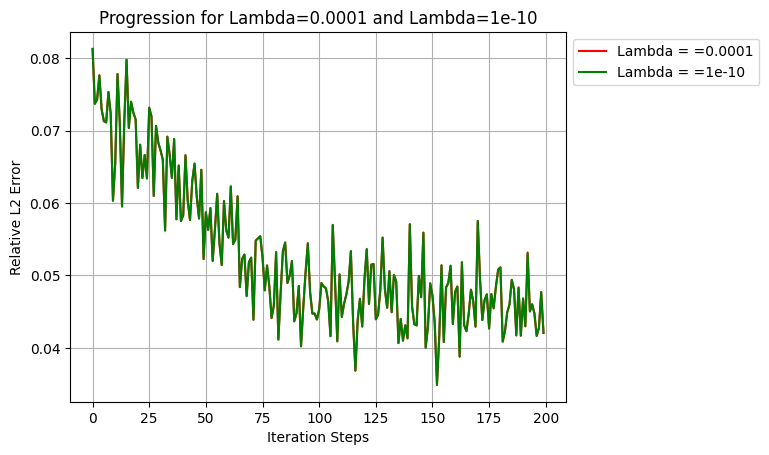

In [6]:

# Instantiate the GP model and Adam optimizer
optimizer = [None] * 2
gp_model = [None] * 2

# Train the model using Adam and cross-validation
num_steps = 200  # Number of optimization steps

# Define a matrix containing the lambda values and the corresponding cross-validation error
alpha_error_matrix = torch.zeros((2, num_steps))


# Generate data for f and u based on GP(0, K)
f_realizations, u_realizations = generate_f_u_from_gp(num_realizations, N, periodic_kernel, length_scale=0.2)

# Solve the system for each realization with up to max_iter Newton iterations.
v_solutions = torch.cat(
    [classical_newton_method_gen_data(f_realizations[j], u_realizations[j], forward_map_alpha_to_flux, lambda_reg = 1e-15, learning_rate=1, max_iter=num_newton_iter)
     for j in range(num_realizations)], dim=0)


f = torch.repeat_interleave(f_realizations, repeats=num_newton_iter, dim=0)
X_data = v_solutions


lambda_reg1 = 1e-4
lambda_reg2 = 1e-10


# y_data_groundtruth = inverse_map_tri(v_solutions, N, lambda_reg)
y_data1 = inverse_map_sparse_cholesky(v_solutions, lambda_reg1, Perm, sparsity)
y_data2 = inverse_map_sparse_cholesky(v_solutions, lambda_reg2, Perm, sparsity)

# Instantiate the GP model and Adam optimizer
gp_model[0] = GaussianProcess(length_scale=1.0)
optimizer[0] = optim.Adam(gp_model[0].parameters(), lr=1e-2)
gp_model[1] = GaussianProcess(length_scale=1.0)
optimizer[1] = optim.Adam(gp_model[1].parameters(), lr=1e-2)


for step in range(num_steps):

    # Step the schedulerloss_value
    # scheduler.step(loss_value)

    # Number of training samples you want
    num_training = int(0.8 * len(X_data))  # 80% train, for instance

    # Shuffle all indices in a random permutation
    indices = torch.randperm(len(X_data))

    # Take the first part for training
    train_indices = indices[:num_training]
    X_train = X_data[train_indices]
    y_train1 = y_data1[train_indices]
    y_train2 = y_data2[train_indices]


    # The rest for testing
    test_indices = indices[num_training:]
    X_test = X_data[test_indices]
    y_pred_test1 = y_data1[test_indices]
    y_pred_test2 = y_data2[test_indices]


    loss_value1 = train_step(gp_model[0], X_train, y_train1, optimizer[0])
    loss_value2 = train_step(gp_model[1], X_train, y_train2, optimizer[1])

    # Step the schedulerloss_value
    # scheduler.step(loss_value)

    with torch.no_grad():
        gp_model[0].fit(X_train, y_train1)
        y_pred_test_pca1 = gp_model[0](X_test)
        gp_model[1].fit(X_train, y_train2)
        y_pred_test_pca2 = gp_model[1](X_test)

    # Calculate relative L2 error
    rl2error1 = torch.mean(torch.norm(y_pred_test_pca1 - y_pred_test1, dim=1) / torch.norm(y_pred_test1, dim=1)).item()
    # r2error_A_inv = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1) / torch.norm(y_pred_test, dim=1)).item()
    l2error1 = torch.mean(torch.norm(y_pred_test_pca1 - y_pred_test1, dim=1)).item()
    l2error_pred_inverse1 = torch.mean(torch.norm(y_pred_test_pca1, dim=1)).item()
    l2error_comp_inverse1 = torch.mean(torch.norm(y_pred_test1, dim=1)).item()

    # Calculate relative L2 error
    rl2error2 = torch.mean(torch.norm(y_pred_test_pca2 - y_pred_test2, dim=1) / torch.norm(y_pred_test2, dim=1)).item()
    # r2error_A_inv = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1) / torch.norm(y_pred_test, dim=1)).item()
    l2error2 = torch.mean(torch.norm(y_pred_test_pca2 - y_pred_test2, dim=1)).item()
    l2error_pred_inverse2 = torch.mean(torch.norm(y_pred_test_pca2, dim=1)).item()
    l2error_comp_inverse2 = torch.mean(torch.norm(y_pred_test2, dim=1)).item()

    current_lr1 = optimizer[0].param_groups[0]['lr']
    alpha_error_matrix[0, step] = rl2error1

    current_lr2 = optimizer[1].param_groups[0]['lr']
    alpha_error_matrix[1, step] = rl2error2

    print(
        f"Lambda: {lambda_reg1}, Step {step}, Loss: {loss_value1.item()}, Rel. L2 err: {rl2error1}, L2 err: {l2error1}, L2 Pred Inv: {l2error_pred_inverse1}, L2 Comp Inv: {l2error_comp_inverse1}, Learning Rate: {current_lr1}")
    print(
        f"Lambda: {lambda_reg2}, Step {step}, Loss: {loss_value1.item()}, Rel. L2 err: {rl2error2}, L2 err: {l2error2}, L2 Pred Inv: {l2error_pred_inverse2}, L2 Comp Inv: {l2error_comp_inverse2}, Learning Rate: {current_lr2}")


# Plotting
def plot_results(matrix, num_steps):
    # Convert matrix to numpy for easier plotting
    result_numpy = matrix.numpy()

    # Define a list of colors for each alpha (7 values, 7 colors)
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']  # Red, Green, Blue, Cyan, Magenta, Yellow, Black

    # Plot for each alpha
    plt.plot(range(num_steps), result_numpy[0, :], label=f'Lambda = ={lambda_reg1}', color=colors[0])
    plt.plot(range(num_steps), result_numpy[1, :], label=f'Lambda = ={lambda_reg2}', color=colors[1])

    # Add labels and legend
    plt.xlabel('Iteration Steps')
    plt.ylabel('Relative L2 Error')
    plt.title(f'Progression for Lambda={lambda_reg1} and Lambda={lambda_reg2}')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.show()


# Call the plot function
plot_results(alpha_error_matrix, num_steps)


# Generating Training Data

In [7]:
import torch

gammas_flat  = []
lambdas_flat = []

with torch.no_grad():
    for gamma in X_data:                     # X_data: iterable or tensor [N, ...]
        Lambda = forward_map_alpha_to_flux(gamma)
        gammas_flat.append(gamma.reshape(-1))    # flatten γᵢ
        lambdas_flat.append(Lambda.reshape(-1))  # flatten Λᵢ

Gamma_mat_  = torch.stack(gammas_flat,  dim=0)    # [N, D_gamma]
Lambda_mat_ = torch.stack(lambdas_flat, dim=0)    # [N, D_lambda]

torch.save({"Lambda": Lambda_mat_, "Gamma": Gamma_mat_}, "./data/InverseScatteringTraining.pt")

# 1) Load saved matrices (each row is a flattened sample)
payload = torch.load("./data/InverseScatteringTraining.pt", map_location="cpu")
Gamma_loaded  = payload["Gamma"]   # [N, D_gamma]
Lambda_loaded = payload["Lambda"]  # [N, D_lambda]

eps_ = 1e-12

# Global relative Frobenius errors
gamma_relF  = torch.norm(Gamma_loaded - Gamma_mat_)  / (torch.norm(Gamma_mat_)  + eps_)
lambda_relF = torch.norm(Lambda_loaded - Lambda_mat_) / (torch.norm(Lambda_mat_) + eps_)

print(f"Gamma global rel Frobenius:  {gamma_relF:.3e}")
print(f"Lambda global rel Frobenius: {lambda_relF:.3e}")


Gamma global rel Frobenius:  0.000e+00
Lambda global rel Frobenius: 0.000e+00


In [8]:
def Deep_Newton(model, Lambda_g, gamma_0, forward_map_alpha_to_flux, lambda_reg, learning_rate, max_iter, c1, beta,
                tol=1e-6):
    gamma_0_flat = gamma_0.flatten()
    gamma_n = gamma_0_flat.clone()
    gamma_n = gamma_n.detach()

    for i in range(max_iter):

        # Prepare the inputs for GP prediction
        X_train = gamma_n.unsqueeze(0)  # No need to cat if there's only one tensor
        with torch.no_grad():  # Disable gradients for inference
            L_elem = model.forward(X_train)

        L = recon_tril(L_elem)

        # Convert sparse tensor to dense for validation
        # nonzeros_indices = non_zeros(N * N, sparsity)  # Calculating the non zero indices
        # U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        # sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N * N, N * N))
        # U_dense = sparse_tensor.to_dense()
        # invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        # A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        # Solve the Newton iteration
        F_n = forward_map_alpha_to_flux(gamma_n) - Lambda_g
        DF_n = torch.func.jacfwd(forward_map_alpha_to_flux)(gamma_n).detach()

        # Compute the right-hand side of the linear system
        d = - DF_n.T @ F_n

        # Solve the system A_inv @ rhs to find delta_v
        # delta_gamma = A_inv @ d
        delta_gamma = torch.linalg.solve_triangular(L.T, torch.linalg.solve_triangular(L,  d.unsqueeze(-1), upper=False), upper=True)
        delta_gamma = delta_gamma.squeeze(-1)  # Optional: back to 1D

        # delta_gamma = torch.linalg.solve_triangular(L.T, torch.linalg.solve_triangular(L, d, upper=False), upper=True)

        alpha = learning_rate  # Initial step size
        gamma_trial = gamma_n + alpha * delta_gamma
        F_n_delta = forward_map_alpha_to_flux(gamma_trial) - Lambda_g

        #
        while torch.norm(F_n_delta) ** 2 >= torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_gamma):
            alpha *= beta  # Reduce step size
            gamma_trial = gamma_n + alpha * delta_gamma
            F_n_delta = forward_map_alpha_to_flux(gamma_trial) - Lambda_g

        # Update rule: v_{n+1} = v_n + delta_v
        gamma_n += alpha * delta_gamma.squeeze()
        # if i % 100 == 0:  # Check if i is divisible by 100
        #     print(alpha)

    gamma = gamma_n.reshape(N, N)
    return gamma


In [9]:
def Deep_Newton_rl2_history(model, Lambda_g, gamma_0,  gamma_truth, forward_map_alpha_to_flux, lambda_reg, learning_rate, max_iter, c1, beta, tol=1e-6):
    gamma_0_flat = gamma_0.flatten()
    gamma_n = gamma_0_flat.clone()
    gamma_n = gamma_n.detach()

    rl2_history = []

    for i in range(max_iter):

        # Prepare the inputs for GP prediction
        X_train = gamma_n.unsqueeze(0)  # No need to cat if there's only one tensor
        with torch.no_grad():  # Disable gradients for inference
            L_elem = model.forward(X_train)

        L = recon_tril(L_elem)

        # Convert sparse tensor to dense for validation
        # nonzeros_indices = non_zeros(N * N, sparsity)  # Calculating the non zero indices
        # U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        # sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N * N, N * N))
        # U_dense = sparse_tensor.to_dense()
        # invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        # A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        # Solve the Newton iteration
        F_n = forward_map_alpha_to_flux(gamma_n) - Lambda_g
        DF_n = torch.func.jacfwd(forward_map_alpha_to_flux)(gamma_n).detach()

        # Compute the right-hand side of the linear system
        d = - DF_n.T @ F_n

        # Solve the system A_inv @ rhs to find delta_v
        # delta_gamma = A_inv @ d
        delta_gamma = torch.linalg.solve_triangular(L.T, torch.linalg.solve_triangular(L,  d.unsqueeze(-1), upper=False), upper=True)
        delta_gamma = delta_gamma.squeeze(-1)  # Optional: back to 1D

        # delta_gamma = torch.linalg.solve_triangular(L.T, torch.linalg.solve_triangular(L, d, upper=False), upper=True)

        alpha = learning_rate  # Initial step size
        gamma_trial = gamma_n + alpha * delta_gamma
        F_n_delta = forward_map_alpha_to_flux(gamma_trial) - Lambda_g

        #
        while torch.norm(F_n_delta) ** 2 >= torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_gamma):
            alpha *= beta  # Reduce step size
            gamma_trial = gamma_n + alpha * delta_gamma
            F_n_delta = forward_map_alpha_to_flux(gamma_trial) - Lambda_g

        # Update rule: v_{n+1} = v_n + delta_v
        gamma_n += alpha * delta_gamma.squeeze()
        # if i % 100 == 0:  # Check if i is divisible by 100
        #     print(alpha)

        rl2_history.append(torch.linalg.norm(gamma_n - gamma_truth) / torch.linalg.norm(gamma_truth))

    gamma = gamma_n.reshape(N, N)
    return gamma, rl2_history

In [29]:
num_times = 10 
times = torch.empty(num_times)
for i in range(num_times):
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = gp_model[1].forward(torch.rand(1,49))
    times[i] = time.perf_counter()-t0
print("times\n%s"%str(times))
print("times.median(): %.1e"%times.median())

times
tensor([0.0310, 0.0012, 0.0011, 0.0010, 0.0015, 0.0009, 0.0010, 0.0010, 0.0011,
        0.0849])
times.median(): 1.1e-03


In [27]:
import time

# Generating Solutions using the GP sampled data
num_test_data = 200

torch.random.manual_seed(0)

Lambda_g, gamma_realizations = generate_f_u_from_gp(num_test_data, N, periodic_kernel, length_scale=0.2)
v_vals2 = gamma_realizations
f_vals1 = torch.cat([(forward_map_alpha_to_flux(gamma_realizations[i, :])).unsqueeze(0)
                     for i in range(gamma_realizations.size(0))], dim=0)

gamma_solutions = v_vals2[:, ::1]
Lambda_g_realizations = f_vals1[:, ::1]
gamma_0 = torch.ones_like(gamma_solutions[0])  # Initial guess v0

# Initialize a variable to accumulate the relative errors
relative_error_sum = 0.0
error_sum = 0.0


rl2_histories = []

# Loop through each realization
for j in range(num_test_data):


    # # Initial guess with relative error
    relative_error = 0.03
    mean_gamma1 = torch.mean(gamma_solutions[j, :].reshape(N,N))  # Average value of Gamma2
    noise_std1 = relative_error * mean_gamma1  # Standard deviation of noise
    noise1 = torch.randn_like(gamma_solutions[j, :].reshape(N,N)) * noise_std1 # Add Gaussian noise with calculated standard deviation
    gamma_0 = gamma_solutions[j, :].reshape(N,N) + noise1
    gamma_0 = torch.clamp(gamma_0, min=0.0) # Ensure Gamma2_noisy remains positive


    # gamma_pre = Deep_Newton(gp_model[0], Lambda_g_realizations[j, :], gamma_0, forward_map_alpha_to_flux, lambda_reg1,
    #                         learning_rate=1, max_iter=100, c1=1e-4,
    #                         beta=0.5, tol=1e-16)

    # Record the start time
    # start_time = time.time()
    #
    #
    # gamma_pre = Deep_Newton(gp_model[0], Lambda_g_realizations[j, :], gamma_0, forward_map_alpha_to_flux, lambda_reg1, learning_rate=1, max_iter=1000, c1=1e-4, beta=0.5, tol=1e-16)
    #
    #
    # # Record the end time
    # end_time = time.time()
    # elapsed = end_time - start_time
    # print(f"Elapsed time: {elapsed:.4f} seconds for Deep Newton")

     # Record the start time
    start_time = time.time()

    # gamma_class = newton_method_for_F(Lambda_g_realizations[j, :], gamma_0, forward_map_alpha_to_flux, lambda_reg=1e-13, learning_rate=1.0,
    #                              max_iter=10, c1=1e-4, beta=0.5, delta=0.0, tol=1e-16)

    # gamma_class = Deep_Newton(gp_model[1], Lambda_g_realizations[j, :], gamma_pre, forward_map_alpha_to_flux, lambda_reg2, learning_rate=1, max_iter=2000, c1=1e-4, beta=0.5, tol=1e-16)

    gamma_class, rl2_history = Deep_Newton_rl2_history(gp_model[1], Lambda_g_realizations[j, :], gamma_0, gamma_solutions[j, :], forward_map_alpha_to_flux, lambda_reg2, learning_rate = 1, max_iter = 2000, c1=1e-4, beta=0.3, tol=1e-6)

    rl2_histories.append(rl2_history)

    # Record the end time
    end_time = time.time()
    elapsed = end_time - start_time
    print(f"Elapsed time: {elapsed:.4f} seconds for Classic Newton")

    exact_sol = gamma_solutions[j, :].reshape(N,N)

    # Correct the corner as they can not be reconstructed or just leave out the outer layer. This has no weight when the resolution is increased and can then be ignored

    # gamma_pre[0,0] = exact_sol[0,0]
    # gamma_pre[-1,0] = exact_sol[-1,0]
    # gamma_pre[-1,-1] = exact_sol[-1,-1]
    # gamma_pre[0,-1] = exact_sol[0,-1]
    #
    # gamma_class[0,0] = exact_sol[0,0]
    # gamma_class[-1,0] = exact_sol[-1,0]
    # gamma_class[-1,-1] = exact_sol[-1,-1]
    # gamma_class[0,-1] = exact_sol[0,-1]

    # Calculate the relative L2 error for the current realization
    # rl2error = (torch.norm(exact_sol - gamma_pre) / torch.norm(exact_sol))
    # l2error = torch.norm(exact_sol - gamma_pre)

     # Calculate the relative L2 error for the current realization
    rl2error2 = (torch.norm(exact_sol - gamma_class) / torch.norm(exact_sol))
    l2error2 = torch.norm(exact_sol - gamma_class)
    #

    # print(f"{j}, Deep Newton: Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}, Classic Newton: Total Rel. L2 err: {rl2error2}, Total L2 err: {l2error2}")

    print(f"{j}, Deep Newton: Total Rel. Total Rel. L2 err: {rl2error2}, Total L2 err: {l2error2}")

    # Calculate the squared relative L2 error for the current realization
    rl2error = rl2error2 ** 2
    l2error = l2error2 ** 2

    # Accumulate the error
    relative_error_sum += rl2error.item()
    error_sum += l2error.item()


rl2_histories_plot = torch.stack([torch.stack(row, dim=0) for row in rl2_histories], dim=0)

# Calculate the mean relative error by dividing by the number of realizations
mean_relative_error = relative_error_sum / num_test_data
mean_error = error_sum / num_test_data

# Take the square root
sqrt_mean_relative_error = mean_relative_error ** 0.5
sqrt_mean_error = mean_error ** 0.5

print(f"Total Rel. L2 err: {mean_relative_error}, Total L2 err: {mean_error}")
print(f"Total Rel. L2 err: {mean_relative_error ** 4}, Total L2 err: {mean_error}")

Elapsed time: 163.8278 seconds for Classic Newton
0, Deep Newton: Total Rel. Total Rel. L2 err: 1.895377070067862e-12, Total L2 err: 5.297728724985609e-12
Elapsed time: 169.4171 seconds for Classic Newton
1, Deep Newton: Total Rel. Total Rel. L2 err: 5.196168737307423e-12, Total L2 err: 2.2991294939424708e-11
Elapsed time: 173.7611 seconds for Classic Newton
2, Deep Newton: Total Rel. Total Rel. L2 err: 7.560764971310958e-13, Total L2 err: 8.57184947818867e-12
Elapsed time: 178.0295 seconds for Classic Newton
3, Deep Newton: Total Rel. Total Rel. L2 err: 3.8317924375248915e-11, Total L2 err: 1.0617529691785057e-10
Elapsed time: 160.9967 seconds for Classic Newton
4, Deep Newton: Total Rel. Total Rel. L2 err: 9.112673404550091e-13, Total L2 err: 1.9927656124984916e-11
Total Rel. L2 err: 3.000516024093798e-22, Total L2 err: 2.460089466068251e-21
Total Rel. L2 err: 8.10557449829459e-87, Total L2 err: 2.460089466068251e-21


# Generating Testing Data

In [11]:
print(gamma_solutions.shape, Lambda_g_realizations.shape)

torch.Size([200, 49]) torch.Size([200, 784])


In [12]:
import torch

gammas_flat  = []
lambdas_flat = []

with torch.no_grad():
    for gamma in gamma_solutions:                     # X_data: iterable or tensor [N, ...]
        Lambda = forward_map_alpha_to_flux(gamma)
        gammas_flat.append(gamma.reshape(-1))    # flatten γᵢ
        lambdas_flat.append(Lambda.reshape(-1))  # flatten Λᵢ

Gamma_mat_  = torch.stack(gammas_flat,  dim=0)    # [N, D_gamma]
Lambda_mat_ = torch.stack(lambdas_flat, dim=0)    # [N, D_lambda]

torch.save({"Lambda": Lambda_mat_, "Gamma": Gamma_mat_}, "./data/InverseScatteringTesting.pt")

# 1) Load saved matrices (each row is a flattened sample)
payload = torch.load("./data/InverseScatteringTesting.pt", map_location="cpu")
Gamma_loaded  = payload["Gamma"]   # [N, D_gamma]
Lambda_loaded = payload["Lambda"]  # [N, D_lambda]

eps_ = 1e-12

print(Lambda_mat_.shape, Gamma_mat_.shape)
# Global relative Frobenius errors
gamma_relF  = torch.norm(Gamma_loaded - Gamma_mat_)  / (torch.norm(Gamma_mat_)  + eps_)
lambda_relF = torch.norm(Lambda_loaded - Lambda_mat_) / (torch.norm(Lambda_mat_) + eps_)

print(f"Gamma global rel Frobenius:  {gamma_relF:.3e}")
print(f"Lambda global rel Frobenius: {lambda_relF:.3e}")

torch.Size([200, 784]) torch.Size([200, 49])
Gamma global rel Frobenius:  0.000e+00
Lambda global rel Frobenius: 0.000e+00


In [13]:
import numpy as np
mask = ~torch.isnan(rl2_histories_plot).any(dim=1)
rl2_histories_plot_no_nan = rl2_histories_plot[mask, :]
rl2_histories_plot_no_nan.shape

torch.Size([198, 2000])

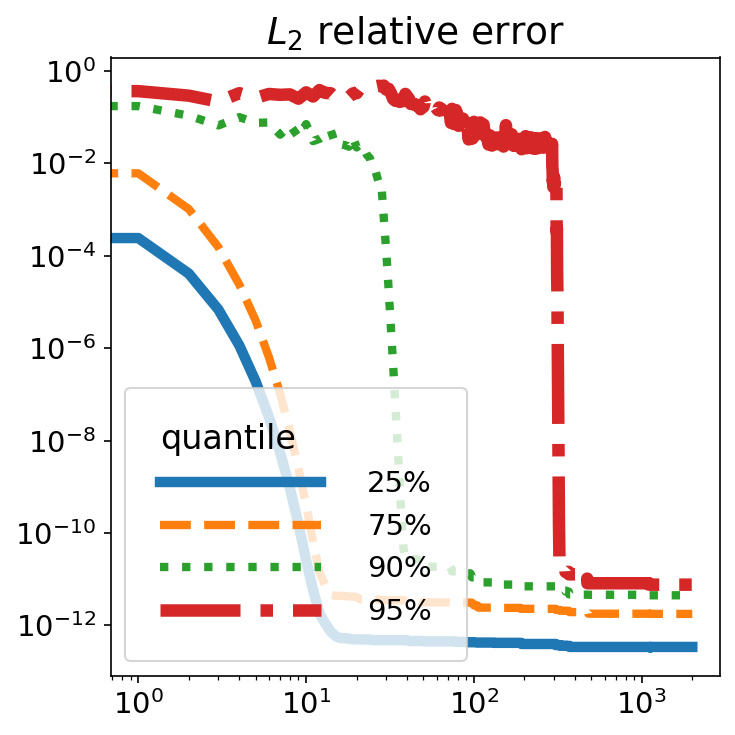

In [14]:
import torch
import matplotlib.pyplot as plt

# Quantiles to plot (order matches line styles)
quantiles = [0.25, 0.75, 0.90, 0.95]

# Compute curves across samples on dim=0
qs = torch.tensor(quantiles, device=rl2_histories_plot_no_nan.device)
quantile_curves = torch.quantile(rl2_histories_plot_no_nan, qs, dim=0)

# X axis
x = torch.arange(rl2_histories_plot_no_nan.shape[-1], device=rl2_histories_plot_no_nan.device)

# Styles (same mapping as before)
linestyles = ["solid", "dashed", "dotted", "dashdot"]
linewidths = [5, 4, 4, 6]   # optional: make 95% a bit thicker

plt.figure(figsize=(5, 5), dpi=150)

for i, q in enumerate(quantiles):
    plt.plot(
        x.cpu().numpy(),
        quantile_curves[i].detach().cpu().numpy(),
        linestyle=linestyles[i],
        linewidth=linewidths[i],
        label=f"{int(q*100)}%"
    )

# Axes/legend to match previous style
plt.xscale("log")
plt.yscale("log")
plt.title(r"$L_2$ relative error", fontsize=18)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
leg = plt.legend(
    title="quantile", fontsize=14, title_fontsize=16,
    loc="lower left", handlelength=5.5, handletextpad=1.6, borderpad=1.2
)
leg._legend_box.align = "left"

plt.grid(False)
plt.tight_layout()
plt.savefig("./result/l2_relative_error_quantiles_only.png", bbox_inches="tight")
plt.show()


In [15]:
import torch

# rl2_histories_plot: shape [num_runs, T]
# e.g., rl2_histories_plot = torch.stack(list_of_runs)  # each run length T

# Choose the five quantiles:
qs = torch.tensor([0.25, 0.75, 0.90, 0.95])  # qll, ql, qm, qh, qhh (dim=0 = runs)
qll, ql, qh, qhh = torch.quantile(rl2_histories_plot_no_nan, qs, dim=0)

# Save everything you need to plot later
to_save = {
    "qll": qll, "ql": ql, "qh": qh, "qhh": qhh,
    "T": rl2_histories_plot.shape[-1]
}
torch.save(to_save, "./result/inverse_scattering_l2_relative_error_quantiles.pt")
print("Saved quantiles to l2_relative_error_quantiles.pt")

Saved quantiles to l2_relative_error_quantiles.pt


In [ ]:
def Deep_Newton_Seq(model, Lambda_g, gamma_0, forward_map_gamma_to_flux, lambda_reg, learning_rate, max_iter, c1, beta, tol=1e-6):
    gamma_0_flat = gamma_0.flatten()
    gamma_n = gamma_0_flat.clone()
    gamma_n = gamma_n.detach()

    gamma_history = []

    for i in range(max_iter):

        # Prepare the inputs for GP prediction
        X_train = gamma_n.unsqueeze(0)  # No need to cat if there's only one tensor
        with torch.no_grad(): # Disable gradients for inference
            # U_sparse = model.forward(X_train)
            L_elem = model.forward(X_train)

        L = recon_tril(L_elem)

        # Convert sparse tensor to dense for validation
        # nonzeros_indices = non_zeros(N*N, sparsity)  # Calculating the non zero indices
        # U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        # sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N*N, N*N))
        # U_dense = sparse_tensor.to_dense()
        # invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        # A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        # Solve the Newton iteration
        F_n = forward_map_gamma_to_flux(gamma_n) - Lambda_g
        DF_n = torch.func.jacfwd(forward_map_gamma_to_flux)(gamma_n).detach()

        # Compute the right-hand side of the linear system
        d = - DF_n.T @ F_n

        # Solve the system A_inv @ rhs to find delta_v
        # delta_gamma = A_inv @ d
        # delta_gamma = torch.linalg.solve_triangular(L.T, torch.linalg.solve_triangular(L, d, upper=False), upper=True)
        delta_gamma = torch.linalg.solve_triangular(L.T, torch.linalg.solve_triangular(L,  d.unsqueeze(-1), upper=False), upper=True)
        delta_gamma = delta_gamma.squeeze(-1)  # Optional: back to 1D

        alpha = learning_rate  # Initial step size
        gamma_trial = gamma_n + alpha * delta_gamma
        F_n_delta = forward_map_gamma_to_flux(gamma_trial) - Lambda_g

        while torch.norm(F_n_delta)**2 >= torch.norm(F_n)**2 +  2*c1 * alpha * torch.dot(d, delta_gamma):
            alpha *= beta  # Reduce step size
            gamma_trial = gamma_n + alpha * delta_gamma
            F_n_delta = forward_map_gamma_to_flux(gamma_trial) - Lambda_g

        # Update rule: v_{n+1} = v_n + delta_v
        gamma_n += alpha * delta_gamma.squeeze()
        # if i % 100 == 0:  # Check if i is divisible by 100
        #     print(alpha)

        gamma_history.append(gamma_n.reshape(N, N).detach().clone())

    gamma = gamma_n.reshape(N, N)
    return gamma, gamma_history

tensor(1.9042e-13)


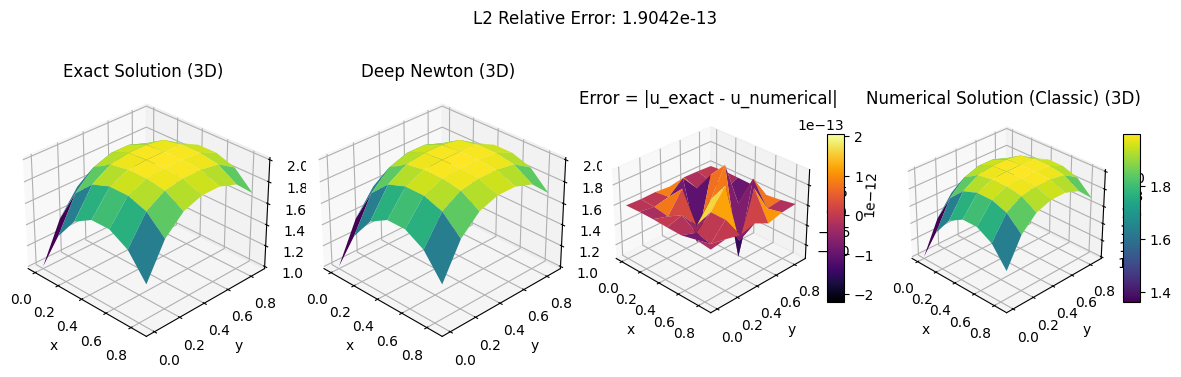

In [17]:

import matplotlib.pyplot as plt


# Define a positive function (e.g., Gaussian-like function)
# Gamma = torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.1) + 1.0  # A
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.cos(torch.pi * Y)
# Gamma = 1.0 + 0.5 * torch.sin(2 * torch.pi * X) * torch.sin(2 * torch.pi * Y)
# Gamma = 1.0 + torch.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2)
# Gamma = 1.0 + torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.2)
# Gamma = 1.0 + (X ** 2 + Y ** 2)
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.exp(-Y)
# Gamma = 1.0 + torch.abs(torch.sin(torch.pi * X) + torch.cos(torch.pi * Y))
# Gamma = 1.0 + torch.sin(torch.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2) * 1 * torch.pi)
Gamma = 1.0 + torch.cos(((X - 0.5) ** 2 + (Y - 0.5) ** 2 ) * 1 * torch.pi)
# Gamma = 1.0 + torch.relu(torch.sin(2 * torch.pi * X) * torch.cos(2 *torch.pi * Y))
# Gamma = 1.0 + torch.log1p((X - 0.5) ** 2 + (Y - 0.5) ** 2)
# Gamma = 1.0 + torch.abs(torch.sin(2 * torch.pi * X) * torch.cos(2 *torch.pi * Y))


# Flatten the function values
gamma_exact = Gamma.flatten()
Lambda_g = forward_map_alpha_to_flux(gamma_exact)
gamma_0 = torch.ones((N, N), device = device)

gamma_0 = gamma_0.to(device)
gam_0 = gamma_0.flatten()

# Initial guess with relative error
relative_error = 0.03
mean_gamma1 = torch.mean(Gamma)  # Average value of Gamma2
noise_std1 = relative_error * mean_gamma1  # Standard deviation of noise
noise1 = torch.randn_like(Gamma) * noise_std1 # Add Gaussian noise with calculated standard deviation
gamma_0 = Gamma + noise1
gamma_0 = torch.clamp(gamma_0, min=0.0) # Ensure Gamma2_noisy remains positive

Lambda_g = Lambda_g.to(device)


gamma_classic = newton_method_for_F(Lambda_g, gamma_0.flatten(), forward_map_alpha_to_flux, lambda_reg=1e-10, learning_rate=1.0, max_iter=100, c1=1e-4, beta=0.5, delta=0, tol=1e-16)

gamma_comp, gamma_history = Deep_Newton_Seq(gp_model[1], Lambda_g, gamma_0.flatten(), forward_map_alpha_to_flux, lambda_reg2, learning_rate = 1, max_iter = 1000, c1=1e-4, beta=0.5, tol=1e-6)

l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)
print(l2_error)


X_np = X.numpy()
Y_np = Y.numpy()

u_exact_np = Gamma.numpy()
u_numerical_np = gamma_comp.numpy()
u_classic = gamma_classic.numpy()

error = gamma_comp - Gamma
error_np = error.numpy()
l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)

fig = plt.figure(figsize=(12, 4))

# 3D plot of Exact Solution
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, u_exact_np, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Exact Solution (3D)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
# fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# Adjust viewing angle so that (1,1) is more towards the front
ax1.view_init(elev=30, azim=-45)

# 3D plot of Numerical Solution
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
surf2 = ax2.plot_surface(X_np, Y_np, u_numerical_np, cmap="viridis", linewidth=0, antialiased=True)
ax2.set_title("Deep Newton (3D)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')
# fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
ax2.view_init(elev=30, azim=-45)

# 3D plot of Error
ax3 = fig.add_subplot(1, 4, 3, projection='3d')
surf3 = ax3.plot_surface(X_np, Y_np, error_np, cmap="inferno", linewidth=0, antialiased=True)
ax3.set_title("Error = |u_exact - u_numerical|")
ax3.set_xlabel('x')
ax3.set_ylabel('y')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)
ax3.view_init(elev=30, azim=-45)

# 3D plot of Exact Solution
ax1 = fig.add_subplot(1, 4,4, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, u_classic, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Numerical Solution (Classic) (3D)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# Adjust viewing angle so that (1,1) is more towards the front
ax1.view_init(elev=30, azim=-45)

plt.suptitle(f"L2 Relative Error: {l2_error:.4e}")
plt.tight_layout()
plt.show()

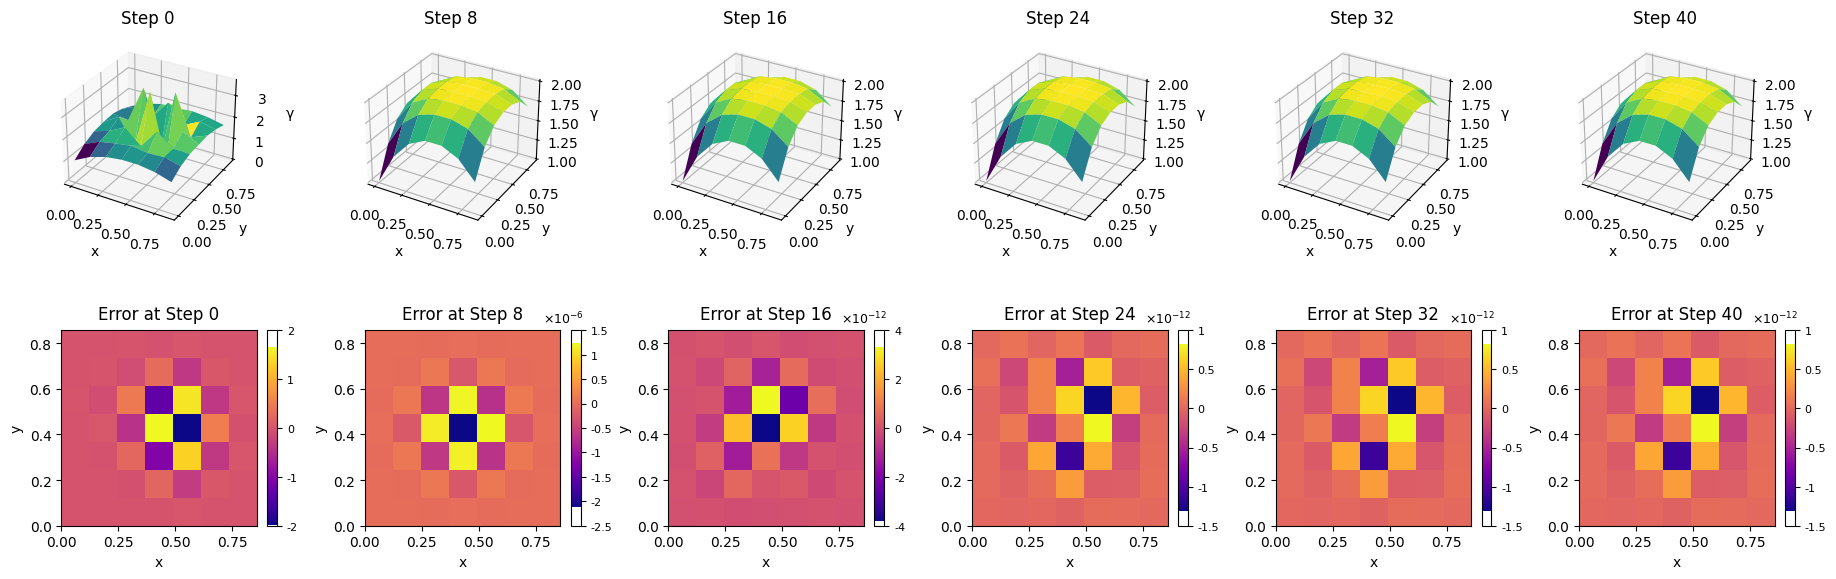

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import numpy as np

plt.style.use('default')

# Select steps
num_plots = 6
total_iters = len(gamma_history)
indices = torch.linspace(0, 40, steps=num_plots).long()

fig = plt.figure(figsize=(3.2 * num_plots, 6))

for i, idx in enumerate(indices):
    gamma_i = gamma_history[idx].numpy()
    error_i = (gamma_history[idx] - Gamma).numpy()

    # Clean any bad values
    error_i = np.nan_to_num(error_i, nan=0.0, posinf=0.0, neginf=0.0)

    # Compute scale per image
    max_abs = np.max(np.abs(error_i))
    if max_abs == 0:
        scale_exp = 0
    else:
        scale_exp = int(np.floor(np.log10(max_abs)))
    scale_factor = 10 ** scale_exp
    scaled_error = error_i / scale_factor
    scale_label = r"$\times 10^{{{}}}$".format(scale_exp)

    # --- Top Row: 3D solution plot ---
    ax1 = fig.add_subplot(2, num_plots, i + 1, projection='3d')
    ax1.plot_surface(X_np, Y_np, gamma_i, cmap='viridis', edgecolor='none', antialiased=True)
    ax1.set_title(f"Step {idx.item()}", pad=10)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('γ')
    ax1.view_init(elev=30, azim=-60)

    # --- Bottom Row: 2D error imshow ---
    ax2 = fig.add_subplot(2, num_plots, i + 1 + num_plots)
    im = ax2.imshow(scaled_error, origin='lower', cmap='plasma',
                    extent=[X_np.min(), X_np.max(), Y_np.min(), Y_np.max()])
    ax2.set_title(f"Error at Step {idx.item()}", pad=8)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')

    # Add colorbar with clean numeric ticks
    cbar = plt.colorbar(im, ax=ax2, orientation='vertical',
                        fraction=0.046, pad=0.04)
    tick_values = cbar.get_ticks()
    cbar.set_ticks(tick_values)
    cbar.set_ticklabels([f"{int(v)}" if v.is_integer() else f"{v:.1f}" for v in tick_values])
    cbar.ax.tick_params(labelsize=8)

    # Add scale label at top-right inside each subplot
    if scale_exp == 0:
        scale_label = ""
    else:
        scale_label = r"$\times 10^{{{}}}$".format(scale_exp)

    ax2.text(1.12, 1.02, scale_label,
             transform=ax2.transAxes,
             fontsize=9,
             ha='right', va='bottom')

# Final layout
plt.tight_layout(pad=2.0)
plt.subplots_adjust(top=0.92, wspace=0.15, hspace=0.5)

# Save to disk
os.makedirs('./result', exist_ok=True)
plt.savefig('./result/inverse_scattering_deep_newton_gp.png',
            dpi=300, bbox_inches='tight', transparent=False)

tensor(1.2041e-11)


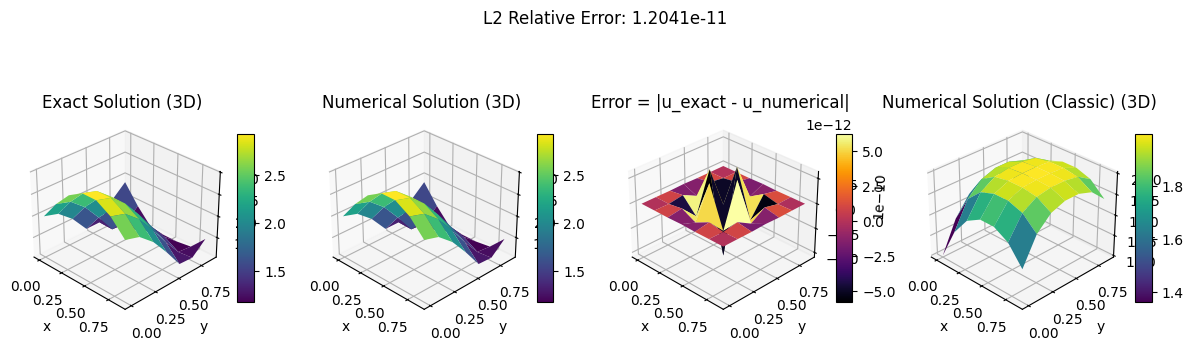

In [19]:

# Reconstruction for solutions that are given by an explicit formula

import matplotlib.pyplot as plt

# Define a positive function (e.g., Gaussian-like function)
# Gamma = torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.1) + 1.0  # A
# Gamma1 = 1.0 + torch.sin(torch.pi * X) * torch.cos(torch.pi * Y)
# Define a positive function (e.g., Gaussian-like function)
# Gamma = torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.1) + 1.0  # A
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.cos(torch.pi * Y)
# Gamma = 1.0 + torch.sin(2 * torch.pi * X) * torch.sin(2 * torch.pi * Y)
# Gamma = 1.0 + torch.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2)
# Gamma = 1.0 + torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.2)
# Gamma = 1.0 + (X ** 2 + Y ** 2)
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.exp(-Y)
Gamma = 1.0 + torch.abs(torch.sin(torch.pi * X) + torch.cos(torch.pi * Y))
# Gamma = 1.0 + torch.sin(torch.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2) * 1 * torch.pi)
# Gamma = 1.0 + torch.relu(torch.sin(2 * torch.pi * X) * torch.cos(2 * torch.pi * Y))
# Gamma = 1.0 + torch.log1p((X - 0.5) ** 2 + (Y - 0.5) ** 2)
# Gamma = 1.0 + torch.abs(torch.sin(2 * torch.pi * X) * torch.cos(2 *torch.pi * Y))


# Flatten the function values
gamma_exact = Gamma.flatten()
Lambda_g = forward_map_alpha_to_flux(gamma_exact)
gamma_0 = torch.ones((N, N), device=device)

gamma_0 = gamma_0.to(device)
Lambda_g = Lambda_g.to(device)


# gamma_classic = newton_method_for_F(Lambda_g, gamma_0, forward_map_alpha_to_flux, lambda_reg=1e-15, learning_rate=1.0,
#                                     max_iter=100, tol=1e-16)
gamma_comp = Deep_Newton(gp_model[0], Lambda_g, gamma_0, forward_map_alpha_to_flux, lambda_reg1, learning_rate=0.1, max_iter=500, c1=1e-4, beta=0.5, tol=1e-6)
gamma_comp = Deep_Newton(gp_model[1], Lambda_g, gamma_comp, forward_map_alpha_to_flux, lambda_reg2, learning_rate=0.1, max_iter=500, c1=1e-4, beta=0.5, tol=1e-6)


l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)
print(l2_error)

X_np = X.numpy()
Y_np = Y.numpy()

u_exact_np = Gamma.numpy()
u_numerical_np = gamma_comp.numpy()
# u_classic = gamma_classic.numpy()

error = gamma_comp - Gamma
error_np = error.numpy()
l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)

fig = plt.figure(figsize=(12, 4))

# 3D plot of Exact Solution
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, u_exact_np, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Exact Solution (3D)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# Adjust viewing angle so that (1,1) is more towards the front
ax1.view_init(elev=30, azim=-45)

# 3D plot of Numerical Solution
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
surf2 = ax2.plot_surface(X_np, Y_np, u_numerical_np, cmap="viridis", linewidth=0, antialiased=True)
ax2.set_title("Numerical Solution (3D)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
ax2.view_init(elev=30, azim=-45)

# 3D plot of Error
ax3 = fig.add_subplot(1, 4, 3, projection='3d')
surf3 = ax3.plot_surface(X_np, Y_np, error_np, cmap="inferno", linewidth=0, antialiased=True)
ax3.set_title("Error = |u_exact - u_numerical|")
ax3.set_xlabel('x')
ax3.set_ylabel('y')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)
ax3.view_init(elev=30, azim=-45)

# 3D plot of Exact Solution
ax1 = fig.add_subplot(1, 4, 4, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, u_classic, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Numerical Solution (Classic) (3D)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# Adjust viewing angle so that (1,1) is more towards the front
ax1.view_init(elev=30, azim=-45)

plt.suptitle(f"L2 Relative Error: {l2_error:.4e}")
plt.tight_layout()
plt.show()